# GivingLens: Smarter Blood Donation Outreach
**Prepared for Isha Khatri | AICTE–IBM SkillsBuild Data Analytics with AI Internship 2026 | BharatCares**

## 1. The question
A volunteer team may have time to contact 30 people, while its donor list contains hundreds. Which records should it review first? GivingLens studies whether past donation behaviour can help rank outreach candidates. It combines exploratory analysis, model comparison and a contact-budget experiment.

This is a reproducible academic prototype. It uses public historical data from Taiwan, not private NGO records or data collected by Isha. The model estimates the historical March 2007 outcome. It does not establish eligibility, consent, future availability or the effect of contacting someone. The project name and outreach analysis are custom; the dataset and classification task are established public resources.

Run every cell in order. No network connection or API key is needed after installing the libraries.

In [1]:
from pathlib import Path
import base64, hashlib, io, json, zlib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display
from sklearn.base import clone
from sklearn.dummy import DummyClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import StratifiedGroupKFold, cross_validate
from sklearn.metrics import (accuracy_score, balanced_accuracy_score, precision_score,
    recall_score, f1_score, roc_auc_score, average_precision_score,
    brier_score_loss, ConfusionMatrixDisplay, PrecisionRecallDisplay)
SEED = 42
OUTPUT = Path('givinglens_outputs')
OUTPUT.mkdir(exist_ok=True)
plt.rcParams.update({'figure.figsize': (9, 5), 'axes.spines.top': False,
                     'axes.spines.right': False, 'font.size': 11})
print('GivingLens environment ready. Random seed:', SEED)

GivingLens environment ready. Random seed: 42


## 2. Dataset and provenance
Source: [UCI Blood Transfusion Service Center](https://archive.ics.uci.edu/dataset/176/blood+transfusion+service+center).

Citation: Yeh, I. (2008). *Blood Transfusion Service Center* [Dataset]. UCI Machine Learning Repository. https://doi.org/10.24432/C5GS39. License: CC BY 4.0.

The source has 748 records and four inputs: months since last donation, total donations, cumulative blood volume in cc, and months since first donation. The target records donation in March 2007. Despite the original column name “Monetary”, the variable is blood volume, not money. A compressed copy is embedded below so the four-file submission works offline; the original bytes are checked using SHA-256.

In [2]:
DATA_B64 = 'eJzNWstu3UYM3QfIP1x01QBCq9E89QPdZVP0B1LnAi7Q2KjroujfV9KQPCRHdh3k1Y0B0RwOh+/H/fl6c727+efy/Yf7u8fbP99MPz1c//irgx5/+3DdIG/v766P7x42wM0PNz9cfv39/v79m+mX7Z849d3ft9fH2+vD5fb645+318v7+7t3j9f3Hfny293l7buHm9vLMs/1u9evlsuU5ykseZ6ntV2m8PrVvP2NU9xA09IhYftbpjRvODEfkO3YMm8nN0jKjLOkqeyQWi/T/PpVukxpCgfK8b2dqVOo+3VJyC5TZLIdZZ2W4+blQNnAqUwhKPa2s0uc8k4nt+PUxnCc9m+5J2wE9iOKf3pRqoyzkd1RgjwoH2LYLmNASBtfO/tNIHmKx0UrQwYqwsn4uf8N01JJsJaN4il2wCoS2QFdqsLXzBA+kwSF5So329dtgLZpcBdROM4EkCWppkGMpxDWl/DPllJEG3wTxEjc7coI5gHFyz4LCtkOGcYCleboNVj4ZgU4w0iw4rL6Bwm3BIhCdZkOEbzskzWeyhnEqHzBIRJQXphPZhyWtG7iy5pxFrOQZYk1r5rWdR5xc3AeuqxOefB7NoG0et7k4m70nbGIa6tYBMUFes3MQhPzZS4y2ybpIAdPoZwDdsJ1SvuZKv6sL9Gf4exT0Xv+9PgJe17iCbkXPUBZRfNmIv7pLn3mE5olRSb74I8iFpQR7y+0OmtsW6yAJiphT5LgYe0gg0hxRh1FL+z1VVCIKkVDOPniwwABirKNmRMI3ZNX5n4g0o06DDmmJOcHpHTFWTnBmPXzdt5taGzd84NKq8WrMokIWBtFgjmhZEl3jFJX66VBiKgXG3tL4kCEEb1VD5KOyT+wnB9RGM06Wpg9X5IyWUarFA04YtwPVQW/vjWnztVzXodb+pEVcW5110pQIn1TnMvIYnABCP38u5OUmG50VEYj9BzgO5z+n81CPJAlJcFc7ATing7xi4Xy5/z/+Awf8/kNeT6UQjGDDHMH2TyTvJOlEzfsRrBIbaBcai9256eTC92rCkRyiBBN/UC8cbyWcDW4t/XmhgoZPQCfkbzDNij8W8DA7SE4rplcmQVPoGuopFyRObypUwcQgi92UGonEROdGXltnEqMxw0IWoqAcCJ3FSXURURqGY6AeRMKEtva5/0MX4vy8xe9BJmc4rM/OKA4oCAZkqlTyO65GoheQWJL3mK5OY5Mg4vcxgAuSnocO2qBjUhGUsK7s6BIbbOyJ5gkAI9MsC7pNzrZquIDkAyZ/waggKjwY072Qdg1GS7otk7SbEfhaFBMQ2k9OVYnloaC1T4RsSuBf07XVQocauaiY0ViColyJBq5+TEUtAgk5RPvXPFFRNUgL5b4NwvI1tvVBZEz3p5ktohdi/CdICniHyhti4+zFAj6SQ1I3PLNAuJHkTEnX2I394KdsMqF1sRcX0LiXTUJd0kTCCq/YDnrOjvOsrHMPk8rm1OJ7RQCF1dSsMVs8GHhiwDEbimNBVX3pYH56my7AoWcKooNKskRxJTVmmzzKizimhT3ysxK7PF3PfuEyldPsA6mNlQyFZGUgyD5WIbNkiOi4M+IVlyZQNIco2cxHo5Fg4pduuerlbusbXhDG+gOWYgrmuIbHwcJJlaWRShbjYgWFx+lx4BbYBxdS1QIrSeBg2VHffpmM7FtPZx6NuocVT6B7rcFkNkBwNYxP4FSfNBIXvNQT0KEIFEXG9G4VlSj+ALRstQGbl15VAOo2EivZF9hl3hQ6Brj8j4PzjY4+AJzYl+Tlr5jsF8hywQrpyyeSJeU7K9NkD6N2mcf+jNkS0pN3xrA9f3ywjPrSQRnGsiNJBLlOwxxsTOvHqMMNqsqDa5t2yrWYw0jOKtVNVqF3QJl10/zxVX06X6JvlhCaFJhhQ4pbyBDUNXTxPPprwpgSeYve80QIGzJCYx6jjEegXtlpBaWM8L3cMhWDEeEN3mjaCfV0Q2Obr5V1mvVl2tK4f2QSnp0aB0emJ2R8MwhovinQwH915o9+ygsKK76Lokf4DGOi2xrBdfgujF6nZ4BiDeWgvCWZyf8GP01zVNtyAp9YBX+x4Dw0iOjwVqHXFSAJDPAyE613IeMKqjYNgqCTl7yqsDrgObtkTWucuQquZbTMcgSb/FbA1hqeA7x2ooXQXMvTtBPx1AGbCUN1xkU2Kq7hjOTmDRh7PI11xyd+6QakgFw1A/TAn1WScZqfxk3Ro6LZTLPkxms62Ka2vGgypC08R9Unb8vPstW1MyyztqRwkb7aHiazBDCZqG5Tz+D2WdgMsE4GThU4cWFyy78HMNRGXbTaotHYVGNjvmnIH6ySsUKXCTIzTFubZV5k4zCZc7tfluguFHrMYYEOcWvpH4edJLfw2GDxPNxmVQNK2wudMlusvp1i8yl1Nre/sbCL7uwtbeTK4thifoxDohyHyiKVkc6wI6+0XD6AxA0iQxzbj3AGdfFala2uvlmR6hASPJWmg2I0DkR4g77NFjssBTHNmF4i1+R2RmFotlYs8NenS8ZxjawcNX2z3YFm5zVjTIlJ6jKVGXc5jaGaqnodxJwSL7oDMNucrMTI+6VveOsFxLBGtATe0Z1o7g3S12G0OMWhGXq7AO/RXnhxu955C9KSq+mon+H1LQStLowMiCk1OjHZJJ0hyWgm0RTg69/kRG9EpMziySjBeMqapiF4EMkxHf4EqzeuQ2t5wBJnunTPr/aJmrWgagsT5xWc8Bghifc6kQt3e7sdjoMl8hJbMm7GZewXf4V8qeCB0sj/DiEavrOefGduUptPOcBq2ohxLNQ/yMvHi4k84Oi2QwTqNGswlxbRUx2pQWpqIZJ7bt3yDzMkJM27eABA4YWi9ok2GF28rMGN3dWHfDy1KAZnegwzVOzCE6sLvTG4BnJfrTFOoTsebSQh1XJ81Pd2SijqmD2KYPScIIhkaq6X8hWTBbcaqXARBuQJDHigbJzXfwTo5e/6r75d5N4NEcsPxzgKm3G7fi1JVU7vvFfslNaHN6pGnK3KojD5h8T4uxtKuKRX2FoWf1vhxQjXm7jIIaj09mMfDjz+Ydkoq5lGHyq7Rb5IRWSKhAN8xJ0wrawsrOoYPTXhglrhr3z4Cx4MT01IjqbGfFEaPUoflAxEEnDTO/FE6HsDfQFZ8CIHyhH77gVjT2mEMEDBozPCHATojMUHlH6KaeahsC2zHsVVRpTdECU7EMiqlJ4HsH6X/AYWno='
raw = zlib.decompress(base64.b64decode(DATA_B64))
assert hashlib.sha256(raw).hexdigest() == '96c8e1091b9c037bcaf25a19b24b49d07771cd88689ffd273e056e9e8845ffe7', 'Dataset integrity check failed'
df = pd.read_csv(io.BytesIO(raw))
df.columns = ['recency_months', 'donation_count', 'volume_cc', 'tenure_months', 'donated']
assert df.shape == (748, 5)
assert not df.isna().any().any()
assert set(df['donated'].unique()) == {0, 1}
assert (df[['recency_months','donation_count','volume_cc','tenure_months']] >= 0).all().all()
assert (df['tenure_months'] >= df['recency_months']).all()
df.to_csv(OUTPUT / 'source_data.csv', index=False)
print('Rows:', len(df), '| Missing values:', int(df.isna().sum().sum()))
print('Donation outcome counts:', df['donated'].value_counts().sort_index().to_dict())
print('Repeated full rows:', int(df.duplicated().sum()))
display(df.head())
display(df.describe().round(2))

Rows: 748 | Missing values: 0
Donation outcome counts: {0: 570, 1: 178}
Repeated full rows: 215


,recency_months,donation_count,volume_cc,tenure_months,donated
0,2,50,12500,98,1
1,0,13,3250,28,1
2,1,16,4000,35,1
3,2,20,5000,45,1
4,1,24,6000,77,0


,recency_months,donation_count,volume_cc,tenure_months,donated
count,748.00,748.00,748.00,748.00,748.00
mean,9.51,5.51,1378.68,34.28,0.24
std,8.10,5.84,1459.83,24.38,0.43
min,0.00,1.00,250.00,2.00,0.00
25%,2.75,2.00,500.00,16.00,0.00
50%,7.00,4.00,1000.00,28.00,0.00
75%,14.00,7.00,1750.00,50.00,0.00
max,74.00,50.00,12500.00,98.00,1.00


## 3. Patterns before modelling
The following charts describe the full dataset; they are not used to choose a model. A high accuracy score can be misleading when non-donors form the larger class. Average precision and recall therefore receive attention alongside accuracy.

Repeated rows are retained: the public file has no donor identifiers, so identical records may describe different people. To reduce overly optimistic evaluation, all identical input profiles will be assigned to the same split.

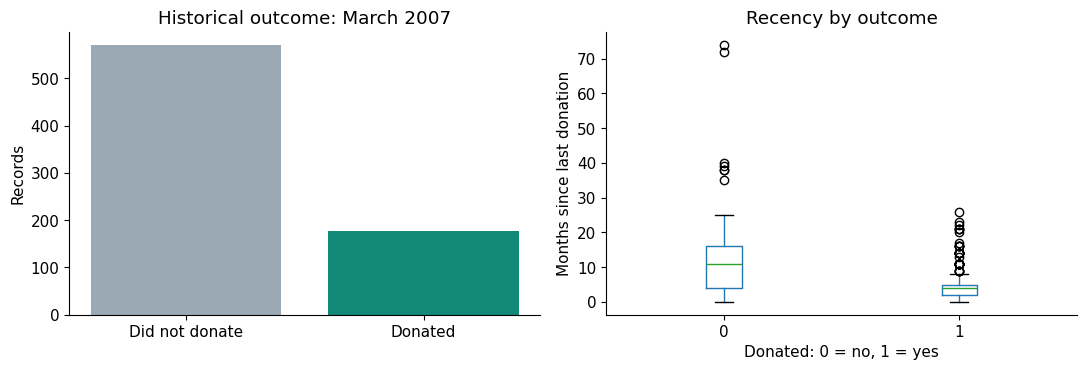

,records,historical_donation_rate
recency_band,,
0–3 months,200,0.375
4–12 months,294,0.276
13+ months,254,0.087


In [3]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4))
counts = df['donated'].value_counts().reindex([0, 1])
axes[0].bar(['Did not donate', 'Donated'], counts, color=['#9aa9b4', '#128878'])
axes[0].set(title='Historical outcome: March 2007', ylabel='Records')
df.boxplot(column='recency_months', by='donated', ax=axes[1], grid=False)
axes[1].set(title='Recency by outcome', xlabel='Donated: 0 = no, 1 = yes', ylabel='Months since last donation')
fig.suptitle('')
fig.tight_layout()
fig.savefig(OUTPUT / 'donation_patterns.png', dpi=180)
plt.show()
segments = df.assign(recency_band=pd.cut(df.recency_months, [-1, 3, 12, np.inf],
    labels=['0–3 months', '4–12 months', '13+ months']))
segment_summary = segments.groupby('recency_band', observed=True)['donated'].agg(['count', 'mean'])
segment_summary.columns = ['records', 'historical_donation_rate']
display(segment_summary.round(3))
segment_summary.to_csv(OUTPUT / 'segment_summary.csv')

## 4. Inputs and a leakage-aware split
Volume is removed because it equals donation count multiplied by 250. Keeping both would duplicate the same signal. Two descriptive features are added: donations per month of recorded tenure and the fraction of tenure spent since the last donation. A denominator floor of one prevents division by zero.

A five-fold stratified group splitter assigns about one fifth of the records to a held-out test set. Only its first split is used. Grouping uses the four original inputs, without the target. Model comparison uses another five-fold group cross-validation inside the training set. The test set is reserved until the model is selected. Grouping prevents identical-profile leakage, but it cannot prove donor-level independence because IDs are unavailable.

In [4]:
assert (df['volume_cc'] == df['donation_count'] * 250).all()
def make_features(frame):
    features = frame[['recency_months', 'donation_count', 'tenure_months']].copy()
    safe_tenure = features['tenure_months'].clip(lower=1)
    features['donations_per_month'] = features['donation_count'] / safe_tenure
    features['recency_fraction'] = features['recency_months'] / safe_tenure
    return features
X = make_features(df)
y = df['donated']
profiles = pd.MultiIndex.from_frame(df[['recency_months','donation_count','volume_cc','tenure_months']])
groups = pd.factorize(profiles)[0]
splitter = StratifiedGroupKFold(n_splits=5, shuffle=True, random_state=SEED)
train_idx, test_idx = next(splitter.split(X, y, groups))
X_train, X_test = X.iloc[train_idx], X.iloc[test_idx]
y_train, y_test = y.iloc[train_idx], y.iloc[test_idx]
groups_train, groups_test = groups[train_idx], groups[test_idx]
assert set(groups_train).isdisjoint(set(groups_test))
cv = list(StratifiedGroupKFold(n_splits=5, shuffle=True, random_state=SEED+1)
    .split(X_train, y_train, groups_train))
for a, b in cv:
    assert set(groups_train[a]).isdisjoint(set(groups_train[b]))
print('Unique input profiles:', len(np.unique(groups)))
print('Training records:', len(train_idx), '| Test records:', len(test_idx))
print('Training positive rate:', round(y_train.mean(), 3), '| Test positive rate:', round(y_test.mean(), 3))

Unique input profiles: 502
Training records: 599 | Test records: 149
Training positive rate: 0.239 | Test positive rate: 0.235


## 5. Compare simple, reproducible models
The candidates are fixed in advance: a majority-class baseline, scaled logistic regression, a constrained random forest, and gradient boosting. Scaling is inside the pipeline, so each cross-validation fold learns it only from its own training records. No oversampling or test-based tuning is performed.

The candidate with the highest mean cross-validation average precision is selected. Average precision summarises the precision–recall ranking: larger values are better. The standard deviation shows variation across the five folds; it is not a confidence interval.

In [5]:
models = {
    'Majority baseline': DummyClassifier(strategy='most_frequent'),
    'Logistic regression': make_pipeline(StandardScaler(), LogisticRegression(max_iter=2000, random_state=SEED)),
    'Random forest': RandomForestClassifier(n_estimators=250, max_depth=5, min_samples_leaf=8, random_state=SEED, n_jobs=1),
    'Gradient boosting': GradientBoostingClassifier(n_estimators=100, learning_rate=0.05, max_depth=2, min_samples_leaf=8, random_state=SEED)
}
cv_rows = []
for name, model in models.items():
    scores = cross_validate(model, X_train, y_train, cv=cv,
        scoring={'ap':'average_precision', 'roc_auc':'roc_auc', 'balanced_acc':'balanced_accuracy'}, n_jobs=1)
    cv_rows.append({'model': name, 'cv_ap_mean': scores['test_ap'].mean(),
        'cv_ap_std': scores['test_ap'].std(ddof=1),
        'cv_roc_auc': scores['test_roc_auc'].mean(),
        'cv_balanced_accuracy': scores['test_balanced_acc'].mean()})
cv_results = pd.DataFrame(cv_rows).sort_values('cv_ap_mean', ascending=False).reset_index(drop=True)
selected_name = cv_results.iloc[0]['model']
selected = clone(models[selected_name]).fit(X_train, y_train)
display(cv_results.round(4))
print('Selected from training CV:', selected_name)
cv_results.to_csv(OUTPUT / 'model_comparison.csv', index=False)

Selected from training CV: Gradient boosting


,model,cv_ap_mean,cv_ap_std,cv_roc_auc,cv_balanced_accuracy
0,Gradient boosting,0.5481,0.1183,0.7531,0.6342
1,Logistic regression,0.5461,0.0786,0.7600,0.6055
2,Random forest,0.5152,0.1096,0.7458,0.6686
3,Majority baseline,0.2387,0.0057,0.5000,0.5000


## 6. Held-out results
The default classification threshold is 0.5 and is fixed before viewing test outcomes. Ranking can still be useful when this threshold misses donors. The confusion matrix, average precision and contact-budget analysis make that distinction visible. Scores are model estimates, not validated individual probabilities.

For context, a simple outreach heuristic ranks the most recently active records first. It is fixed in advance and tested alongside the selected model.

,test_score
accuracy,0.7584
balanced_accuracy,0.5451
precision,0.4545
recall,0.1429
f1,0.2174
roc_auc,0.7361
average_precision,0.4283
brier_score,0.1604


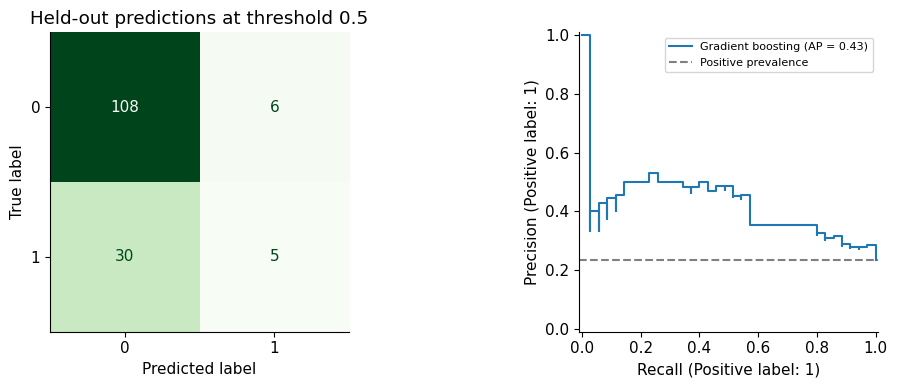

In [6]:
prob = selected.predict_proba(X_test)[:, 1]
pred = (prob >= 0.5).astype(int)
metrics = {'accuracy': accuracy_score(y_test, pred),
    'balanced_accuracy': balanced_accuracy_score(y_test, pred),
    'precision': precision_score(y_test, pred, zero_division=0),
    'recall': recall_score(y_test, pred, zero_division=0),
    'f1': f1_score(y_test, pred, zero_division=0),
    'roc_auc': roc_auc_score(y_test, prob),
    'average_precision': average_precision_score(y_test, prob),
    'brier_score': brier_score_loss(y_test, prob)}
display(pd.Series(metrics, name='test_score').round(4).to_frame())
fig, axes = plt.subplots(1, 2, figsize=(11, 4))
ConfusionMatrixDisplay.from_predictions(y_test, pred, ax=axes[0], colorbar=False, cmap='Greens')
axes[0].set_title('Held-out predictions at threshold 0.5')
PrecisionRecallDisplay.from_predictions(y_test, prob, ax=axes[1], name=selected_name)
axes[1].axhline(y_test.mean(), linestyle='--', color='grey', label='Positive prevalence')
axes[1].legend(fontsize=8)
fig.tight_layout()
fig.savefig(OUTPUT / 'model_evaluation.png', dpi=180)
plt.show()

## 7. Contact-budget experiment: the custom decision layer
For each budget, records are sorted by model score and the top *k* are selected. Precision@k is the fraction of these records whose historical outcome is positive. Recall@k is the share of all test positives captured. Lift compares precision@k with the test set's positive rate, which is the expected precision of random selection.

The recent-first heuristic provides a practical comparison. Random expectations are analytical; no outreach is actually carried out. Stable row order breaks score ties, so small-budget results may depend on tie order. These results measure retrospective ranking, not extra donations caused by a campaign.

,budget_fraction,contacts,model_positive_records,precision_at_k,recall_at_k,lift_vs_random,random_expected_positive_records,recent_first_positive_records,recent_first_precision_at_k
0,0.1,15,8,0.533,0.229,2.270,3.523,8,0.533
1,0.2,30,15,0.500,0.429,2.129,7.047,12,0.400
2,0.3,45,20,0.444,0.571,1.892,10.570,19,0.422
3,0.5,75,27,0.360,0.771,1.533,17.617,27,0.360
4,1.0,149,35,0.235,1.000,1.000,35.000,35,0.235


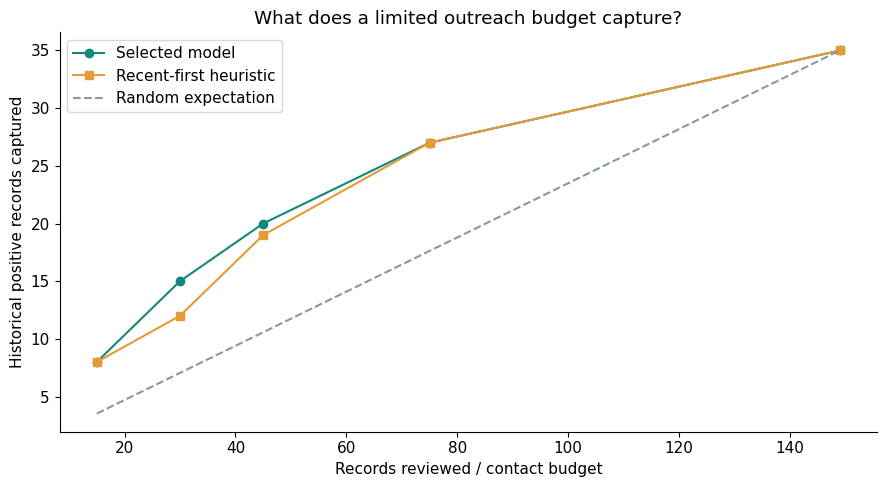

,source_row,recency_months,donation_count,tenure_months,model_score
506,507,3,21,42,0.747
513,514,3,14,35,0.713
528,529,5,24,79,0.701
15,16,2,5,11,0.672
511,512,2,11,26,0.672
512,513,2,11,28,0.659
27,28,4,12,34,0.646
559,560,3,8,50,0.556
505,506,2,41,98,0.549
547,548,2,3,11,0.524


In [7]:
def ranked_budget(scores, outcomes, k):
    order = np.argsort(-np.asarray(scores), kind='stable')[:k]
    hits = int(np.asarray(outcomes)[order].sum())
    return hits, hits/k, hits/int(np.asarray(outcomes).sum())
budget_rows = []
for fraction in [0.10, 0.20, 0.30, 0.50, 1.00]:
    k = max(1, int(np.ceil(len(y_test)*fraction)))
    hits, precision, recall = ranked_budget(prob, y_test, k)
    heuristic_hits, heuristic_precision, _ = ranked_budget(-X_test['recency_months'], y_test, k)
    budget_rows.append({'budget_fraction': fraction, 'contacts': k,
        'model_positive_records': hits, 'precision_at_k': precision, 'recall_at_k': recall,
        'lift_vs_random': precision/y_test.mean(),
        'random_expected_positive_records': k*y_test.mean(),
        'recent_first_positive_records': heuristic_hits,
        'recent_first_precision_at_k': heuristic_precision})
budget_results = pd.DataFrame(budget_rows)
display(budget_results.round(3))
budget_results.to_csv(OUTPUT / 'outreach_budget.csv', index=False)
fig, ax = plt.subplots()
ax.plot(budget_results.contacts, budget_results.model_positive_records, 'o-', label='Selected model', color='#128878')
ax.plot(budget_results.contacts, budget_results.recent_first_positive_records, 's-', label='Recent-first heuristic', color='#e49b36')
ax.plot(budget_results.contacts, budget_results.random_expected_positive_records, '--', label='Random expectation', color='#8998a3')
ax.set(xlabel='Records reviewed / contact budget', ylabel='Historical positive records captured', title='What does a limited outreach budget capture?')
ax.legend()
fig.tight_layout()
fig.savefig(OUTPUT / 'outreach_budget.png', dpi=180)
plt.show()
outreach_preview = df.iloc[test_idx][['recency_months','donation_count','tenure_months']].copy()
outreach_preview.insert(0, 'source_row', test_idx + 1)
outreach_preview['model_score'] = prob
outreach_preview = outreach_preview.sort_values('model_score', ascending=False, kind='stable')
display(outreach_preview.head(10).round(3))
outreach_preview.to_csv(OUTPUT / 'historical_review_queue.csv', index=False)

## 8. A small scoring demo
The input checks reject impossible or incomplete numeric profiles. They are data checks, not medical screening. This model remains fitted only on the training partition so that the report and the demo refer to the same evaluated model. The example below is illustrative and is not a real person's record.

In [8]:
def score_profile(recency_months, donation_count, tenure_months):
    values = np.asarray([recency_months, donation_count, tenure_months], dtype=float)
    if not np.isfinite(values).all() or (values < 0).any():
        raise ValueError('Provide finite, non-negative values.')
    if donation_count < 1 or donation_count != int(donation_count):
        raise ValueError('Donation count must be a positive whole number.')
    if recency_months > tenure_months:
        raise ValueError('Recency cannot exceed months since first donation.')
    record = pd.DataFrame([{'recency_months':recency_months,
        'donation_count':donation_count, 'tenure_months':tenure_months}])
    return float(selected.predict_proba(make_features(record))[0, 1])
print('Illustrative profile score:', round(score_profile(3, 8, 30), 3))
try:
    score_profile(20, 2, 10)
    raise AssertionError('Invalid input was accepted')
except ValueError:
    print('Invalid-profile validation passed.')
summary = {'selected_model': selected_name, 'rows': len(df),
    'unique_profiles': int(len(np.unique(groups))), 'train_records': len(train_idx),
    'test_records': len(test_idx), 'positive_records': int(y.sum()),
    'test_positive_records': int(y_test.sum()), 'full_row_duplicates': int(df.duplicated().sum()),
    'dataset_sha256': hashlib.sha256(raw).hexdigest(), 'metrics': metrics,
    'cv_results': cv_results.to_dict(orient='records'),
    'budgets': budget_results.to_dict(orient='records')}
(OUTPUT / 'results_summary.json').write_text(json.dumps(summary, indent=2))
print('Results exported to:', OUTPUT.resolve())

Illustrative profile score: 0.577
Invalid-profile validation passed.
Results exported to: /workspace/scratch/bf2fd9c7e799/GivingLens_Submission/givinglens_outputs


## 9. What this project shows—and what remains open
GivingLens connects a classifier to a volunteer team's limited review capacity. The main contribution is the transparent outreach-budget comparison, backed by a group-based evaluation and a simple recency heuristic. All measurements come from running this notebook.

The dataset is small, historical and from one centre. A single held-out split cannot establish performance across locations or years. The data contains no consent, contact history, blood group, eligibility or protected demographic attributes, so medical suitability, fairness across demographic groups and campaign impact cannot be assessed. Scores are not calibrated for deployment. Identical-profile grouping reduces one leakage risk but cannot replace donor identifiers or a chronological split.

A next version should use authorised local records with donor identifiers and dated outcomes, evaluate on a later period, check score calibration, obtain consent for any outreach, and test whether outreach changes participation. A trained reviewer must handle eligibility using the centre's procedures. No improvement in real donations is claimed here.

### References and viva prompts
1. Yeh, I. (2008). Blood Transfusion Service Center. UCI. DOI: https://doi.org/10.24432/C5GS39. CC BY 4.0.
2. Scikit-learn documentation: https://scikit-learn.org/stable/ — model selection, grouped cross-validation and metrics.
3. Pandas documentation: https://pandas.pydata.org/docs/ — data loading and summaries.
4. Matplotlib documentation: https://matplotlib.org/stable/ — plots.

**Explain these before submitting:** Why is blood volume removed? Why are identical profiles grouped? Why can accuracy look good while recall is low? How does lift differ from extra donations caused by a campaign? Why does a Taiwan dataset not validate a Nagpur deployment?